# 05 – District Summary and Time Series
Summarize properties per district and analyze price and transaction-volume trends over time.

**Input:** `housing_extended.csv` · **Output:** `data/processed/districts_df.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

housing_extended = pd.read_csv('../data/processed/housing_extended.csv', encoding='gbk')
housing_extended.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


## District-level summary
For each district: mean price per m², share of properties with an elevator / near a subway, mean area, mean building age (relative to 2021), and the most frequent building structure.

In [2]:
districts_df = housing_extended.groupby('district').agg({
    'pricePerSquare': 'mean',
    'square': 'mean',
    'buildingStructure': lambda x: x.mode()[0]
})

districts_df['% houses with elevator'] = (
    housing_extended.groupby('district')['elevator']
    .apply(lambda x: (x == 'has elevator').mean() * 100)
)

districts_df['% houses with subway'] = (
    housing_extended.groupby('district')['subway']
    .apply(lambda x: (x == 'has subway').mean() * 100)
)

districts_df['building age mean'] = (
    housing_extended.groupby('district')['constructionTime']
    .apply(lambda x: (2021 - x).mean())
)

districts_df = districts_df.rename(columns={
    'pricePerSquare': 'pricePerSquare mean',
    'square': 'square mean',
    'buildingStructure': 'frequent buildingStructure'
})

districts_df = districts_df[
    [
        'pricePerSquare mean',
        '% houses with elevator',
        '% houses with subway',
        'square mean',
        'building age mean',
        'frequent buildingStructure'
    ]
].sort_index()

districts_df

,pricePerSquare mean,% houses with elevator,% houses with subway,square mean,building age mean,frequent buildingStructure
district,,,,,,
1,5981.774965,56.216550,93.488404,67.047856,25.151709,steel-concrete composite
2,3805.924811,68.647623,61.825544,76.951352,20.639123,steel-concrete composite
3,3130.333142,66.636691,47.032374,92.071484,15.494604,steel-concrete composite
4,2999.928821,39.983398,43.027117,86.322272,18.324364,mixed
5,2841.761483,80.077031,39.005602,89.297990,11.271359,steel-concrete composite
6,2952.222451,37.892663,43.553669,100.121614,17.536464,mixed
7,4225.965657,66.746216,68.307898,78.845544,22.553717,steel-concrete composite
8,5312.914827,51.883462,61.087404,73.615248,24.191570,steel-concrete composite
9,3491.126972,46.534461,27.636823,73.047513,25.653835,steel-concrete composite


## Parse timestamps
Convert `tradeTime` to `datetime` so `resample` can be used.

In [3]:
housing_extended['tradeTime'] = pd.to_datetime(housing_extended['tradeTime'])
housing_extended.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


## Monthly average price per m²
Transactions before 2010 are too sparse (fewer than 10) and are excluded.

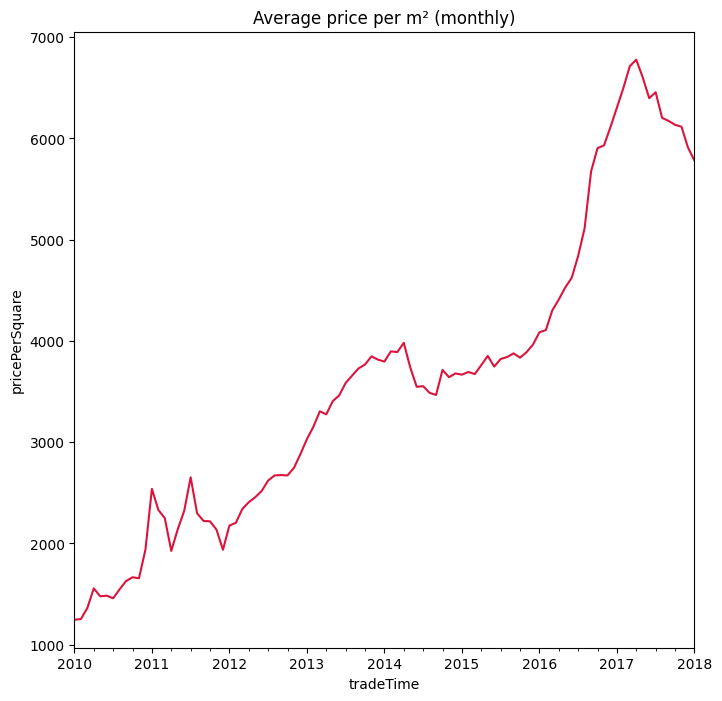

In [4]:
fig1, ax1 = plt.subplots()
fig1.set_size_inches(8, 8)

housing_extended[housing_extended['tradeTime'].dt.year >= 2010] \
    .resample('ME', on='tradeTime')['pricePerSquare'] \
    .mean() \
    .plot(ax=ax1, color='crimson')

ax1.set_title('Average price per m² (monthly)')
ax1.set_xlabel('tradeTime')
ax1.set_ylabel('pricePerSquare')

fig1.savefig('../reports/figures/price_over_time.png', dpi=130, bbox_inches='tight')
plt.show()

## Quarterly transactions near the center
Number of transactions within 15 km of the center, from 2010 onward.

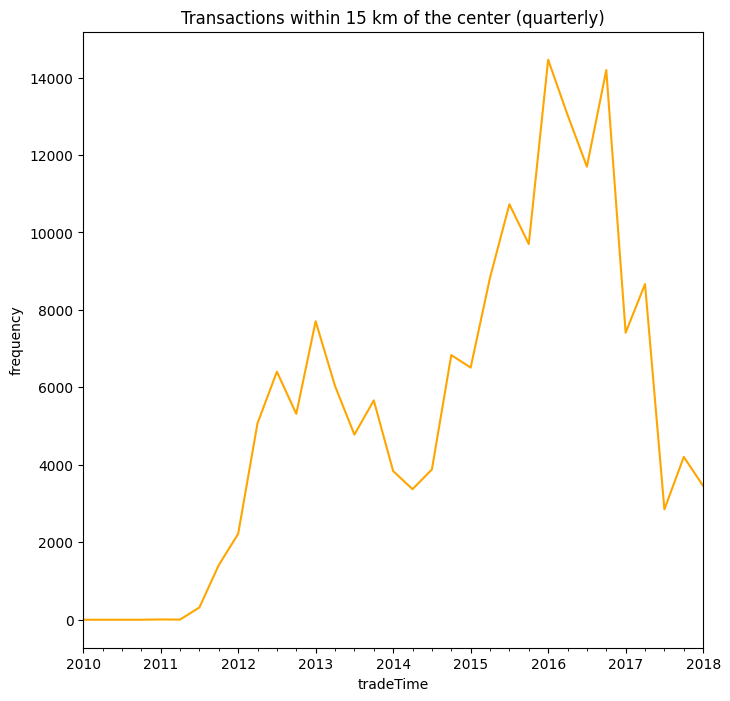

In [5]:
fig2, ax2 = plt.subplots()
fig2.set_size_inches(8, 8)

housing_extended[housing_extended['tradeTime'].dt.year >= 2010] \
    .resample('3ME', on='tradeTime')['distanceToCapital'] \
    .apply(lambda x: (x < 15).sum()) \
    .plot(ax=ax2, color='orange')

ax2.set_title('Transactions within 15 km of the center (quarterly)')
ax2.set_xlabel('tradeTime')
ax2.set_ylabel('frequency')

fig2.savefig('../reports/figures/central_trades_over_time.png', dpi=130, bbox_inches='tight')
plt.show()

## Save

In [6]:
districts_df.to_csv('../data/processed/districts_df.csv', index=True)